# Day 3 — Data Distributions
### 30 Days of Machine Learning | For Data Analysts & Data Scientists

Companion notebook to the Day 3 carousel post. Every cell is executed — outputs, stats, and charts are all baked into this file.

**What we'll cover:**
1. Normal distribution — exam scores
2. Uniform distribution — random arrival times
3. Binomial distribution — coin-flip counts
4. Poisson distribution — rare-event counts (signups per hour)
5. Skewed (log-normal) distribution — session durations, and why mean ≠ median here
6. Side-by-side comparison of all five
7. A simple checklist for identifying which distribution you're looking at


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(42)
pd.set_option('display.precision', 4)

# Palette matching the carousel (Coral Energy)
NAVY = "#2F3C7E"
CORAL = "#F96167"
GOLD = "#F4A300"
GREEN = "#1F9D6B"
INK = "#1C2140"

print("Setup complete.")


Setup complete.


## 1. Normal Distribution — Exam Scores

The classic bell curve: symmetric, most values cluster near the mean, and it tapers off evenly on both sides. Heights, measurement errors, and (often) exam scores follow this shape.


Mean:   72.05
Median: 72.13
Std dev:9.93
Skewness: -0.041  (close to 0 = symmetric)


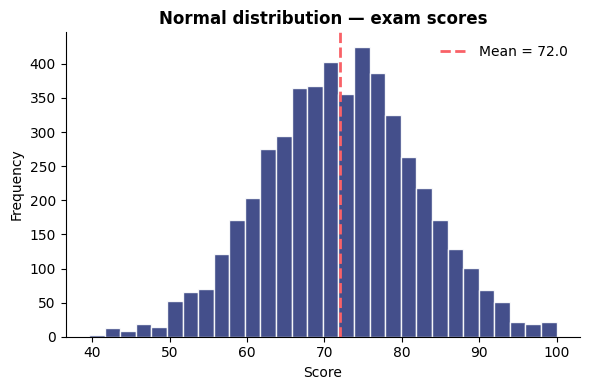

In [2]:
exam_scores = np.random.normal(loc=72, scale=10, size=5000)
exam_scores = np.clip(exam_scores, 0, 100)

print(f"Mean:   {exam_scores.mean():.2f}")
print(f"Median: {np.median(exam_scores):.2f}")
print(f"Std dev:{exam_scores.std():.2f}")
print(f"Skewness: {stats.skew(exam_scores):.3f}  (close to 0 = symmetric)")

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(exam_scores, bins=30, color=NAVY, edgecolor="white", alpha=0.9)
ax.axvline(exam_scores.mean(), color=CORAL, linestyle="--", linewidth=2, label=f"Mean = {exam_scores.mean():.1f}")
ax.set_title("Normal distribution — exam scores", fontsize=12, fontweight="bold")
ax.set_xlabel("Score")
ax.set_ylabel("Frequency")
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig("dist_normal.png", dpi=150, bbox_inches="tight")
plt.show()


**Reading it:** mean ≈ median, skewness ≈ 0. This is the "safe" case — the mean is a trustworthy summary here.

## 2. Uniform Distribution — Random Arrival Times

Every outcome in the range is equally likely. If customers arrive at completely random times within a 60-minute window with no clustering, arrival minute follows a uniform distribution.


Mean:   29.69
Median: 29.51
Min / Max: 0.00 / 59.98


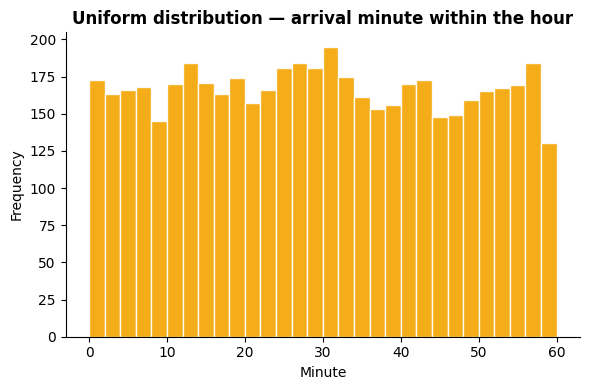

In [3]:
arrival_minutes = np.random.uniform(0, 60, size=5000)

print(f"Mean:   {arrival_minutes.mean():.2f}")
print(f"Median: {np.median(arrival_minutes):.2f}")
print(f"Min / Max: {arrival_minutes.min():.2f} / {arrival_minutes.max():.2f}")

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(arrival_minutes, bins=30, color=GOLD, edgecolor="white", alpha=0.9)
ax.set_title("Uniform distribution — arrival minute within the hour", fontsize=12, fontweight="bold")
ax.set_xlabel("Minute")
ax.set_ylabel("Frequency")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("dist_uniform.png", dpi=150, bbox_inches="tight")
plt.show()


**Reading it:** roughly flat across the range — every bar is about the same height. If your histogram looks like this, there's no "typical" value; the average is only meaningful as a midpoint, not a common outcome.

## 3. Binomial Distribution — Coin-Flip Counts

Counts the number of "successes" in a fixed number of independent yes/no trials. Classic example: flip a coin 20 times, count the heads, repeat that experiment many times.


Mean heads per 20 flips: 10.00  (expected: 10.0)
Std dev: 2.28


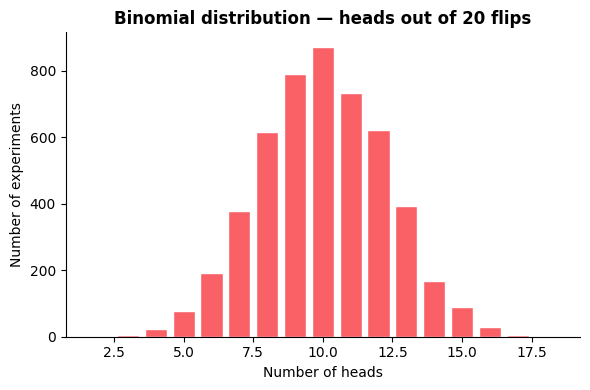

In [4]:
n_trials_per_experiment = 20
n_experiments = 5000
heads_counts = np.random.binomial(n=n_trials_per_experiment, p=0.5, size=n_experiments)

print(f"Mean heads per 20 flips: {heads_counts.mean():.2f}  (expected: {n_trials_per_experiment * 0.5})")
print(f"Std dev: {heads_counts.std():.2f}")

fig, ax = plt.subplots(figsize=(6, 4))
values, counts = np.unique(heads_counts, return_counts=True)
ax.bar(values, counts, color=CORAL, edgecolor="white")
ax.set_title("Binomial distribution — heads out of 20 flips", fontsize=12, fontweight="bold")
ax.set_xlabel("Number of heads")
ax.set_ylabel("Number of experiments")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("dist_binomial.png", dpi=150, bbox_inches="tight")
plt.show()


**Reading it:** discrete (whole numbers only) and bell-shaped when `n` is large enough. This is the distribution behind "what's the chance at least 8 of my 20 A/B test users convert" type questions.

## 4. Poisson Distribution — Rare Events Per Interval

Counts how many times a rare, independent event happens in a fixed window — signups per hour, server errors per minute, support tickets per day.


Mean signups/hour:     4.02  (expected: 4)
Variance:              4.02  (Poisson: variance ≈ mean)
P(0 signups in an hour): 0.017


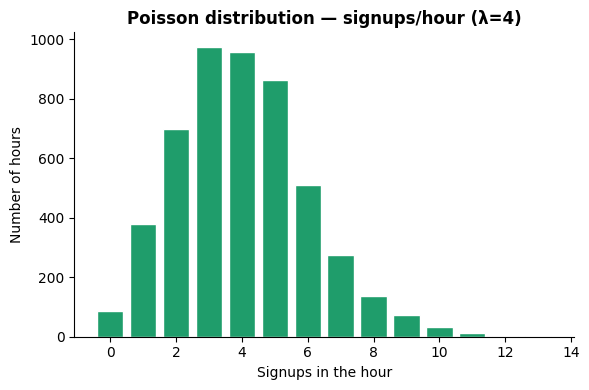

In [5]:
avg_signups_per_hour = 4
hours_observed = 5000
signups = np.random.poisson(lam=avg_signups_per_hour, size=hours_observed)

print(f"Mean signups/hour:     {signups.mean():.2f}  (expected: {avg_signups_per_hour})")
print(f"Variance:              {signups.var():.2f}  (Poisson: variance ≈ mean)")
print(f"P(0 signups in an hour): {(signups == 0).mean():.3f}")

fig, ax = plt.subplots(figsize=(6, 4))
values, counts = np.unique(signups, return_counts=True)
ax.bar(values, counts, color=GREEN, edgecolor="white")
ax.set_title(f"Poisson distribution — signups/hour (λ={avg_signups_per_hour})", fontsize=12, fontweight="bold")
ax.set_xlabel("Signups in the hour")
ax.set_ylabel("Number of hours")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("dist_poisson.png", dpi=150, bbox_inches="tight")
plt.show()


**Reading it:** right-skewed, discrete, and its defining trait is `variance ≈ mean` — check that ratio, and you've got a fast way to tell "is this Poisson-like" without fitting anything.

## 5. Skewed (Log-Normal) Distribution — Session Durations

Most sessions are short, a few run extremely long — the classic long-tail shape. This is where "the mean lied to me" (Day 1) shows up in the wild.


Mean:     6.16 min
Median:   4.42 min
Skewness: 5.38  (> 1 = strongly right-skewed)


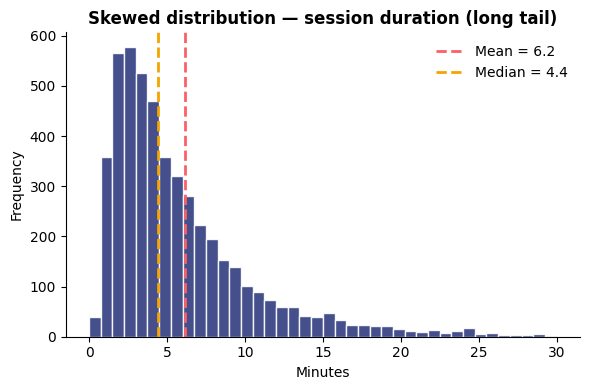

In [6]:
session_minutes = np.random.lognormal(mean=1.5, sigma=0.8, size=5000)

mean_val = session_minutes.mean()
median_val = np.median(session_minutes)
skew_val = stats.skew(session_minutes)

print(f"Mean:     {mean_val:.2f} min")
print(f"Median:   {median_val:.2f} min")
print(f"Skewness: {skew_val:.2f}  (> 1 = strongly right-skewed)")

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(session_minutes, bins=40, color=NAVY, edgecolor="white", alpha=0.9, range=(0, 30))
ax.axvline(mean_val, color=CORAL, linestyle="--", linewidth=2, label=f"Mean = {mean_val:.1f}")
ax.axvline(median_val, color=GOLD, linestyle="--", linewidth=2, label=f"Median = {median_val:.1f}")
ax.set_title("Skewed distribution — session duration (long tail)", fontsize=12, fontweight="bold")
ax.set_xlabel("Minutes")
ax.set_ylabel("Frequency")
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig("dist_skewed.png", dpi=150, bbox_inches="tight")
plt.show()


**Reading it:** mean > median, skewness well above 1 — a handful of very long sessions are dragging the mean up. Report the median here, exactly like the Day 1 rule of thumb.

## 6. Side-by-Side Comparison

Same figure size, same bin logic, so the shape differences are the only thing your eye picks up.


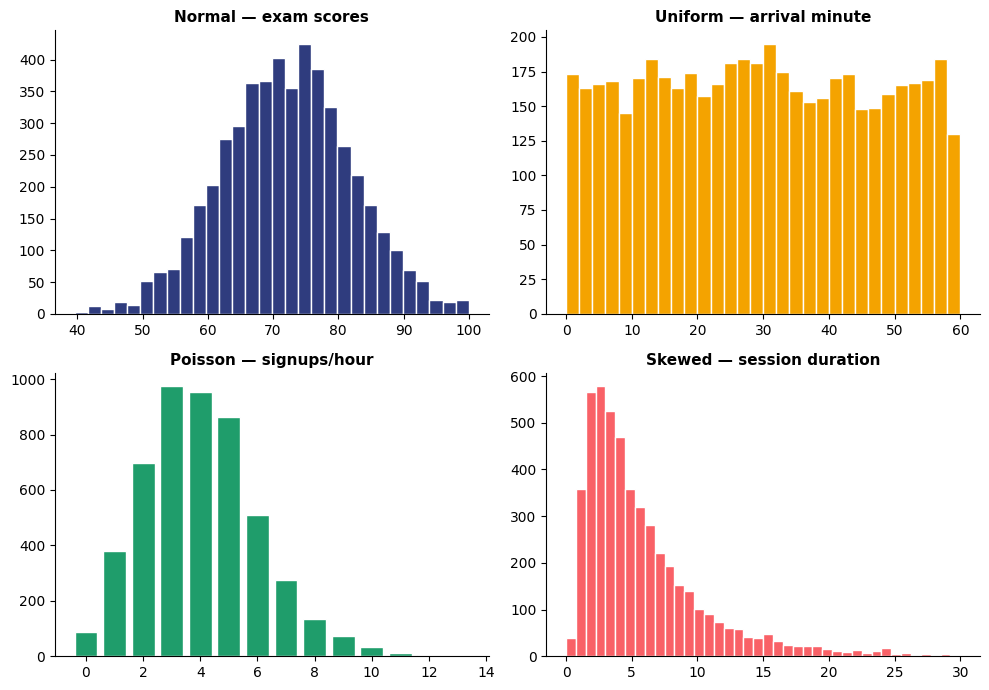

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(10, 7))

axes[0, 0].hist(exam_scores, bins=30, color=NAVY, edgecolor="white")
axes[0, 0].set_title("Normal — exam scores", fontweight="bold", fontsize=11)

axes[0, 1].hist(arrival_minutes, bins=30, color=GOLD, edgecolor="white")
axes[0, 1].set_title("Uniform — arrival minute", fontweight="bold", fontsize=11)

values, counts = np.unique(signups, return_counts=True)
axes[1, 0].bar(values, counts, color=GREEN, edgecolor="white")
axes[1, 0].set_title("Poisson — signups/hour", fontweight="bold", fontsize=11)

axes[1, 1].hist(session_minutes, bins=40, range=(0, 30), color=CORAL, edgecolor="white")
axes[1, 1].set_title("Skewed — session duration", fontweight="bold", fontsize=11)

for ax in axes.flat:
    ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("dist_comparison_grid.png", dpi=150, bbox_inches="tight")
plt.show()


## Cheat Sheet

| Distribution | Shape | Data type | Quick check | Business example |
|---|---|---|---|---|
| Normal | Symmetric bell | Continuous | mean ≈ median | Exam scores, measurement error |
| Uniform | Flat | Continuous or discrete | all bars ~equal height | Random arrival time in a window |
| Binomial | Bell-ish, bounded | Discrete (counts) | fixed number of yes/no trials | A/B test conversions out of N users |
| Poisson | Right-skewed | Discrete (counts) | variance ≈ mean | Signups/hour, errors/day |
| Skewed (log-normal) | Long tail | Continuous | mean > median, skew > 1 | Session duration, income, ratings |

## How To Identify Yours In 3 Steps
1. Plot the histogram — is it symmetric, flat, or does it have a long tail?
2. Compare mean vs. median — a big gap means skew, and you should lead with the median.
3. If it's a count of events in a fixed window, check `variance ≈ mean` — that's the Poisson signature.
